# Figure 3
## Permutation analysis
### Author: Martin Loza
### Date: 25/12/10

After selecting the window for downstream analysis, we will test the observed enrichments using the permutation test.


In [1]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
})

# Local variables 
seed = 777
date = "251210"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_3/Plots/"
ensembl_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/selected/"

# Local Functions
# Function to perform one permutation: shuffle is_TF at the gene level within each chromosome
permute_tf_by_gene_within_chromosome <- function(data) {
    # Step 1: Extract unique PCG genes with their chromosome and TF status
    unique_genes <- data %>%
        select(chromosome, pcg_id, is_TF) %>%
        distinct()
    
    # Step 2: Shuffle TF labels within each chromosome at the gene level
    shuffled_genes <- unique_genes %>%
        group_by(chromosome) %>%
        mutate(is_TF_shuffled = sample(is_TF,replace = FALSE)) %>%
        ungroup() %>%
        select(pcg_id, is_TF_shuffled)
    
    # Step 3: Map the shuffled TF labels back to all observations
    permuted_data <- data %>%
        select(-is_TF) %>%
        left_join(shuffled_genes, by = "pcg_id") %>%
        rename(is_TF = is_TF_shuffled)
    
    return(permuted_data)
}


### Load and setup the data

In [2]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["human"]], 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE


In [3]:
# Let's place an order in the plots
ordered_species <- c("human", "mouse")
# Arrange the data_list according to the ordered_species
data_selected_list <- data_list[ordered_species]

In [4]:
unique(data_selected_list[["human"]]$chromosome)

[1] "19" "12" "14" "1"  "7"  "20" "2"  "11" "22" "Y"  "16" "17" "X"  "3"  "6" 
[16] "10" "21" "9"  "5"  "8"  "15" "4"  "18" "13"

Let's focus only in lncRNAs

In [5]:
# Select only observations related to lncRNA
for (species in names(data_selected_list)) {
    data_selected_list[[species]] <- data_selected_list[[species]] %>%
        filter(gene_biotype == "lncRNA")
}

In [6]:
head(data_selected_list[["human"]], 3)
nrow(data_selected_list[["human"]])
table(data_selected_list[["human"]]$gene_biotype)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE


[1] 4155667


 lncRNA 
4155667 

### Permutation test on TF related to lncRNAs

In [7]:
# Add absolute distance column
for (species in names(data_selected_list)) {
    data_selected_list[[species]] <- data_selected_list[[species]] %>%
        mutate(abs_strand_distance = abs(strand_distance))
}
# Define the window sizes for downstream analysis
window_sizes <- 10000  # 10 kb

# Select only pairs within the defined window sizes
for (species in names(data_selected_list)) {
    data_selected_list[[species]] <- data_selected_list[[species]] %>%
        filter(abs_strand_distance <= window_sizes)
}

cat("Number of lncRNA-PCG pairs within", window_sizes, "bp window in human:\n")
nrow(data_selected_list[["human"]])
cat("Number of lncRNA-PCG pairs within", window_sizes, "bp window in mouse:\n")
nrow(data_selected_list[["mouse"]])

Number of lncRNA-PCG pairs within 10000 bp window in human:


[1] 105579

Number of lncRNA-PCG pairs within 10000 bp window in mouse:


[1] 52957

In [8]:
# UNCOMMENT TO TEST SINGLE TRANSCRIPT FOR EACH LNCRNA-PCG PAIR

# test single ncRNA-PCG pair
# for (species in names(data_selected_list)) {
#     data_selected_list[[species]] <- data_selected_list[[species]] %>%
#         filter(! duplicated(ncrna_gene_name))
# }

#### Calculate observed TF enrichment

In [9]:
# Calculate observed statistics for each species
observed_stats <- list()

for (species in names(data_selected_list)) {
    data <- data_selected_list[[species]]
    
    # Total number of lncRNA-PCG pairs
    total_pairs <- nrow(data)
    
    # Number of TF-lncRNA pairs
    tf_pairs <- sum(data$is_TF, na.rm = TRUE)
    
    # Proportion of TFs
    tf_proportion <- tf_pairs / total_pairs
    
    observed_stats[[species]] <- list(
        total_pairs = total_pairs,
        tf_pairs = tf_pairs,
        tf_proportion = tf_proportion
    )
    
    cat(sprintf("%s:\n", species))
    cat(sprintf("  Total lncRNA-PCG pairs: %d\n", total_pairs))
    cat(sprintf("  TF-lncRNA pairs: %d\n", tf_pairs))
    cat(sprintf("  TF proportion: %.4f (%.2f%%)\n\n", tf_proportion, tf_proportion * 100))
}

human:
  Total lncRNA-PCG pairs: 105579
  TF-lncRNA pairs: 55454
  TF proportion: 0.5252 (52.52%)

mouse:
  Total lncRNA-PCG pairs: 52957
  TF-lncRNA pairs: 7263
  TF proportion: 0.1371 (13.71%)



#### Permutation test: Shuffle TF labels within chromosomes

Before running the permutation test, let's verify the gene-level statistics to understand what we're shuffling:

In [10]:
# Check gene-level statistics
for (species in names(data_selected_list)) {
    data <- data_selected_list[[species]]
    
    # Get unique genes
    unique_genes <- data %>%
        select(pcg_id, pcg_gene_name, chromosome, is_TF) %>%
        distinct()
    
    total_unique_genes <- nrow(unique_genes)
    tf_genes <- sum(unique_genes$is_TF, na.rm = TRUE)
    
    cat(sprintf("%s - Gene-level statistics:\n", species))
    cat(sprintf("  Total unique PCG genes: %d\n", total_unique_genes))
    cat(sprintf("  Unique TF genes: %d\n", tf_genes))
    cat(sprintf("  TF proportion (gene-level): %.4f (%.2f%%)\n", 
                tf_genes/total_unique_genes, (tf_genes/total_unique_genes)*100))
    cat(sprintf("  Compare to pair-level TF proportion: %.4f (%.2f%%)\n\n", 
                observed_stats[[species]]$tf_proportion,
                observed_stats[[species]]$tf_proportion * 100))
}

human - Gene-level statistics:
  Total unique PCG genes: 14976
  Unique TF genes: 1918
  TF proportion (gene-level): 0.1281 (12.81%)
  Compare to pair-level TF proportion: 0.5252 (52.52%)

mouse - Gene-level statistics:
  Total unique PCG genes: 12490
  Unique TF genes: 1264
  TF proportion (gene-level): 0.1012 (10.12%)
  Compare to pair-level TF proportion: 0.1371 (13.71%)



In [11]:
# Set parameters for permutation test
n_permutations <- 10000
set.seed(seed)

# Perform permutations for each species
permutation_results <- list()

for (species in names(data_selected_list)) {
    cat(sprintf("Running %d permutations for %s...\n", n_permutations, species))
    
    data <- data_selected_list[[species]]
    permuted_proportions <- numeric(n_permutations)
    
    # Perform permutations
    for (i in 1:n_permutations) {
        # Shuffle TF labels at gene level within chromosomes
        permuted_data <- permute_tf_by_gene_within_chromosome(data)
        
        # Calculate TF proportion in permuted data
        permuted_proportions[i] <- sum(permuted_data$is_TF, na.rm = TRUE) / nrow(permuted_data)
        
        # Progress indicator
        if (i %% 1000 == 0) {
            cat(sprintf("  Completed %d/%d permutations\n", i, n_permutations))
        }
    }
    
    # Calculate p-value
    observed_prop <- observed_stats[[species]]$tf_proportion
    p_value <- sum(permuted_proportions >= observed_prop) / n_permutations
    
    permutation_results[[species]] <- list(
        permuted_proportions = permuted_proportions,
        p_value = p_value
    )
    
    cat(sprintf("Completed! p-value = %.4f\n\n", p_value))
}

Running 10000 permutations for human...
  Completed 1000/10000 permutations
  Completed 2000/10000 permutations
  Completed 3000/10000 permutations
  Completed 4000/10000 permutations
  Completed 5000/10000 permutations
  Completed 6000/10000 permutations
  Completed 7000/10000 permutations
  Completed 8000/10000 permutations
  Completed 9000/10000 permutations
  Completed 10000/10000 permutations
Completed! p-value = 0.0000

Running 10000 permutations for mouse...
  Completed 1000/10000 permutations
  Completed 2000/10000 permutations
  Completed 3000/10000 permutations
  Completed 4000/10000 permutations
  Completed 5000/10000 permutations
  Completed 6000/10000 permutations
  Completed 7000/10000 permutations
  Completed 8000/10000 permutations
  Completed 9000/10000 permutations
  Completed 10000/10000 permutations
Completed! p-value = 0.0000



#### Visualization of permutation test results

In [14]:
# Create a dataframe for plotting
plot_data <- data.frame()

for (species in names(data_selected_list)) {
    temp_df <- data.frame(
        species = species,
        proportion = permutation_results[[species]]$permuted_proportions,
        type = "Permuted"
    )
    plot_data <- rbind(plot_data, temp_df)
}

# Add observed values
observed_data <- data.frame(
    species = names(data_selected_list),
    proportion = sapply(observed_stats, function(x) x$tf_proportion),
    type = "Observed"
)

# Create histogram plot for each species
plots <- list()

for (species in names(data_selected_list)) {
    species_data <- plot_data %>% filter(species == !!species)
    obs_value <- observed_stats[[species]]$tf_proportion
    p_val <- permutation_results[[species]]$p_value
    
    # Determine significance symbol
    if (p_val < 0.001) {
        sig_symbol <- "***"
    } else if (p_val < 0.01) {
        sig_symbol <- "**"
    } else if (p_val < 0.05) {
        sig_symbol <- "*"
    } else {
        sig_symbol <- "n.s."
    }
    
    p <- ggplot(species_data, aes(x = proportion)) +
        geom_histogram(bins = 30, fill = blue, alpha = 0.7, color = "black") +
        geom_vline(xintercept = obs_value, color = red, linewidth = line_size, linetype = "dashed") +
        labs(
            title = tools::toTitleCase(species),
            x = "TF Proportion",
            y = "Count",
            subtitle = sprintf("Observed = %.4f (%s)", obs_value, sig_symbol)
        ) +
        theme_classic() +
        theme(
            text = element_text(size = text_size),
            plot.title = element_text(hjust = 0.5),
            plot.subtitle = element_text(hjust = 0.5)
        )
    
    plots[[species]] <- p
}

# Display plots
# for (species in names(plots)) {
#     print(plots[[species]])
# }

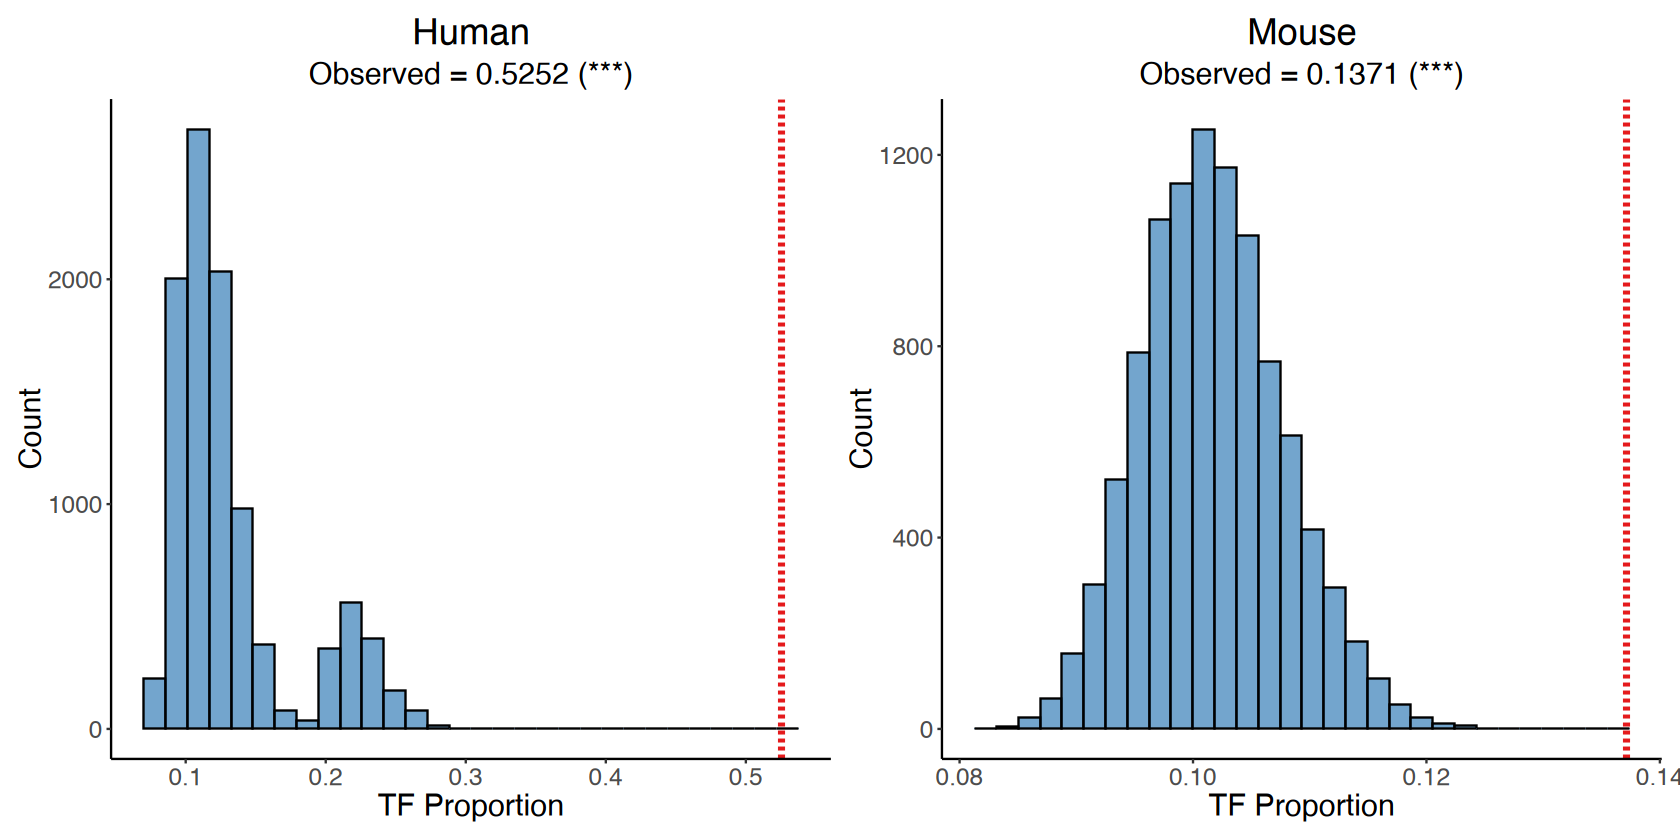

In [15]:
# Create combined plot
combined_plot <- wrap_plots(plots, ncol = 2)
# change the size of the displayed plot
options(repr.plot.width=14, repr.plot.height=7)
combined_plot

In [17]:
# Save the plot
ggsave(
    filename = file.path(out_dir, sprintf("Sup_Fig_permutation_test_TF_enrichment_%s.pdf", date)),
    plot = combined_plot,
    width = width * 0.8,
    units = "in", dpi = dpi
)

# Save the plot for unique transcripts only
# ggsave(
#     filename = file.path(out_dir, sprintf("Sup_Fig_permutation_test_TF_enrichment_unique_lncRNA_transcripts_%s.pdf", date)),
#     plot = combined_plot,
#     width = width * 0.8,
#     height = 5.0, 
#     units = "in", dpi = dpi
# )


Saving 14.9 x 7 in image
